In [1]:
from RoyalFunctions import generate_H
from RoyalFunctions import generate_F
from matplotlib.ticker import FuncFormatter
from matplotlib import cm
import numpy as np
import matplotlib.pyplot as plt

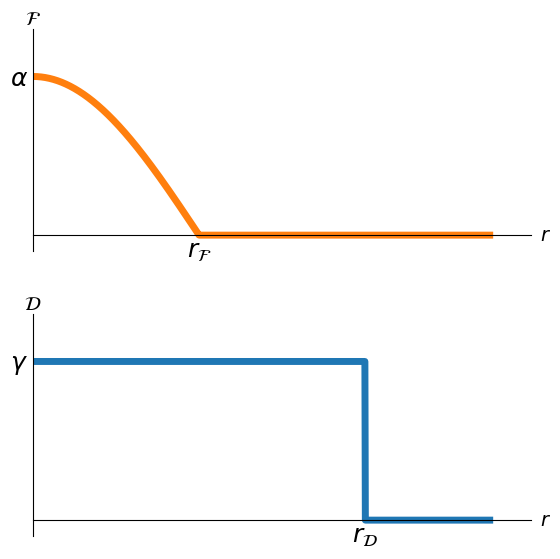

In [2]:
# Increase global font size
plt.rcParams.update({
    'font.size': 20,         # Base font size
    'axes.titlesize': 22,    # Title size (if used)
    'axes.labelsize': 22,    # Axis label size (if used)
    'xtick.labelsize': 18,   # X tick labels
    'ytick.labelsize': 18,   # Y tick labels
    'legend.fontsize': 18,   # Legend (if used)
})
# Parameters
r_D = 2   # radius of resource depletion
gamma = 1   # amount of resource removed
r_F = 1     # radius of erosion
alpha = 0.1 # max erosion depth

# Radial domain
r = np.linspace(0, 2.75, 1000)

# Resource depletion: step function
D = np.where(r <= r_D, gamma, 0)

# Footprint erosion: cosine taper
F = np.where(r <= r_F, alpha * np.cos(np.pi * r / (2 * r_F)), 0)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))

def center_spines(ax):
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')

# === Footprint Erosion Kernel (F) ===
ax1.plot(r, F, lw=5, color='tab:orange')
center_spines(ax1)
ax1.set_xlim(0, 3)
ax1.set_ylim(-0.01, alpha * 1.3)
ax1.set_xticks([r_F])
ax1.set_xticklabels([r'$r_\mathcal{F}$'])
ax1.set_yticks([alpha])
ax1.set_yticklabels([r'$\alpha$'])
ax1.tick_params(axis='both', which='both', length=0)
ax1.grid(False)
ax1.set_xlabel('')
ax1.set_ylabel('')

# Label x- and y-axis tips
ax1.text(3.05, 0.0, r'$r$', va='center', ha='left', fontsize=14)
ax1.text(0.0, alpha * 1.3, r'$\mathcal{F}$', va='bottom', ha='center', fontsize=14)

# === Resource Depletion Kernel (D) ===
ax2.plot(r, D, lw=5, color='tab:blue')
center_spines(ax2)
ax2.set_xlim(0, 3)
ax2.set_ylim(-0.1, gamma * 1.3)
ax2.set_xticks([r_D])
ax2.set_xticklabels([r'$r_\mathcal{D}$'])
ax2.set_yticks([gamma])
ax2.set_yticklabels([r'$\gamma$'])
ax2.tick_params(axis='both', which='both', length=0)
ax2.grid(False)
ax2.set_xlabel('')
ax2.set_ylabel('')

# Label x- and y-axis tips
ax2.text(3.05, 0.0, r'$r$', va='center', ha='left', fontsize=14)
ax2.text(0.0, gamma * 1.3, r'$\mathcal{D}$', va='bottom', ha='center', fontsize=14)

plt.tight_layout()
plt.show()

/tmp/ipykernel_287560/2190568250.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('cool', len(slopes))


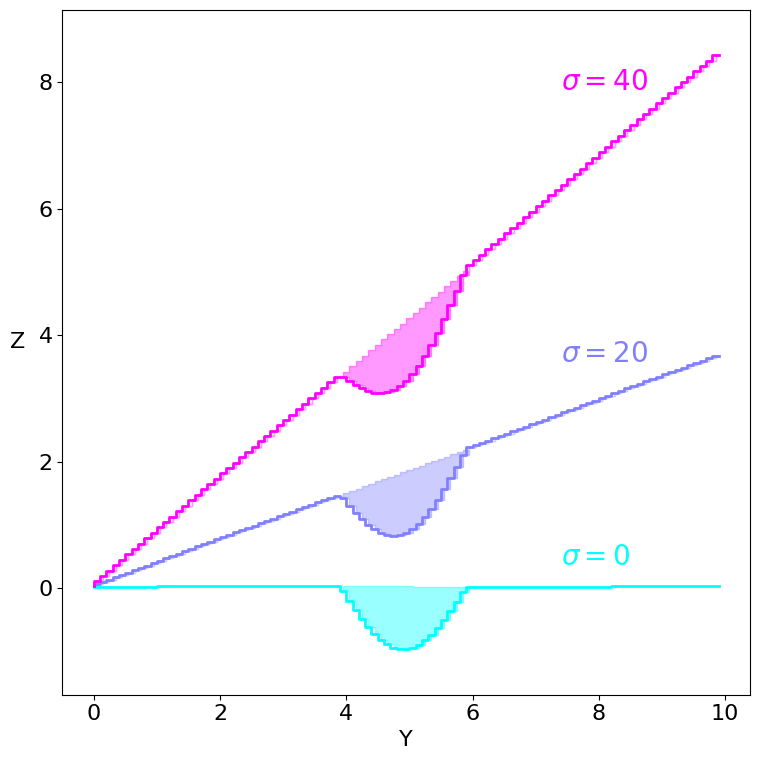

In [3]:
# Define slopes and color map
slopes = [0, 20, 40]
cmap = cm.get_cmap('cool', len(slopes))

fig = plt.figure(figsize=(8, 8))
tempy = [5, 37, 80]
# Generate and plot for each slope
for idx, amplitude in enumerate(slopes): 
    scale = 10       # length of one side of the terrain map in bodylengths 
    resolution = 10  # resolution per body length
    wavelength = 0.5 
    noise_scale = 0

    x, y, elevation_map, size, offsets = generate_H(scale, resolution, amplitude, wavelength, noise_scale)
    opacity = 10
    brush = generate_F(resolution)
    
    # Explicitly define footstep locations for visualization
    sizex, sizey = elevation_map.shape
    brush_sizex, brush_sizey = brush.shape
    brush_radius = brush_sizex // 2
    accumulated_brush = np.zeros((sizex, sizey))
    posx = size // 2
    posy = size // 2
    for i in range(brush_sizex):
        for j in range(brush_sizey):
            canvas_y = int((posx - brush_radius + i) % sizey)
            canvas_x = int((posy - brush_radius + j) % sizex)
            accumulated_brush[canvas_x, canvas_y] += brush[i, j] * opacity
    trampled = elevation_map - accumulated_brush 
    
    # Extract center profile
    profile = trampled[:, int(size // 2)]
    baseline = elevation_map[:, int(size // 2)]
    y_vals = np.arange(len(profile))

    color = cmap(idx)
    plt.step(y_vals, profile, lw=2, color=color)
    plt.fill_between(y_vals, baseline, profile, step='mid', alpha=0.4, color=color)

    # Annotate slope
    text_x = y_vals[-1] -25  # slight offset to the right
    text_y = profile[-1]     # last value in profile for vertical position
    text_y = tempy[idx]
    plt.text(text_x, text_y, fr'$\sigma = {amplitude}$', fontsize=20, color=color, va='center')

# Format tick labels (divide by 10)
def divide_by_10(val, pos):
    return f'{val / 10:.0f}'

plt.gca().xaxis.set_major_formatter(FuncFormatter(divide_by_10))
plt.gca().yaxis.set_major_formatter(FuncFormatter(divide_by_10))

# Plot styling
plt.axis('equal')
plt.xlabel('Y', fontsize=16)
plt.ylabel('Z', rotation=0, labelpad=15, fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.show()
